In [ ]:
!pip install chardet

from google.colab import files
import chardet
import os
from google.colab import files



In [ ]:
print("Please upload your Quaid-e-Azam speeches text file...")
uploaded = files.upload()

Please upload your Quaid-e-Azam speeches text file...


Saving dataquaid_e_azaminput.txt to dataquaid_e_azaminput (1).txt


In [ ]:
# Get the uploaded file name
filename = list(uploaded.keys())[0]

In [ ]:
with open(filename, "rb") as f:
    raw_data = f.read()
    result = chardet.detect(raw_data)

encoding_detected = result['encoding']
confidence = result['confidence']

print(f"Detected encoding: {encoding_detected} (confidence: {confidence})")


Detected encoding: Windows-1252 (confidence: 0.73)


In [ ]:
with open(filename, "r", encoding=encoding_detected, errors="replace") as f:
    text = f.read()

In [ ]:
clean_filename = "quaid_e_azam.txt"
with open(clean_filename, "w", encoding="utf-8") as f:
    f.write(text)

print(f"File converted to UTF-8 and saved as: {clean_filename}")
print(f"File size: {os.path.getsize(clean_filename) / 1024:.2f} KB")

File converted to UTF-8 and saved as: quaid_e_azam.txt
File size: 186.87 KB


In [ ]:
print("FILE PREVIEW")
print(text[:500])

FILE PREVIEW
--- SPEECH START ---
I am glad that I am afforded an opportunity to speak to you directly through this radio from Delhi. It is the first time, I believe, that a non-official has been afforded an opportunity to address the people through the medium of this powerful instrument direct to the people on political matter. It augurs well and I hope that in the future I shall have greater facilities to enable me to voice my views and opinions which will reach you directly.

The statement of His Majesty'


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

with open("quaid_e_azam.txt", "r", encoding="utf-8") as f:
    text = f.read()

In [ ]:
chars = sorted(list(set(text)))
vocab_size = len(chars)
stoi = {ch:i for i,ch in enumerate(chars)}
itos = {i:ch for ch,i in stoi.items()}

encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

data = torch.tensor(encode(text), dtype=torch.long)

In [ ]:
# Train/val split
n = int(0.9*len(data))
train_data = data[:n]
val_data = data[n:]

In [ ]:
block_size = 64
batch_size = 32
max_iters = 5000
eval_interval = 500
learning_rate = 3e-4
device = 'cuda' if torch.cuda.is_available() else 'cpu'
n_embd = 128
n_head = 4
n_layer = 4
dropout = 0.1

torch.manual_seed(1337)

In [ ]:
def get_batch(split):
    data_split = train_data if split == 'train' else val_data
    ix = torch.randint(len(data_split) - block_size, (batch_size,))
    x = torch.stack([data_split[i:i+block_size] for i in ix])
    y = torch.stack([data_split[i+1:i+block_size+1] for i in ix])
    return x.to(device), y.to(device)

In [ ]:
class Head(nn.Module):


    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)      # (B,T,head_size)
        q = self.query(x)    # (B,T,head_size)

        # Compute attention scores ("affinities")
        wei = q @ k.transpose(-2, -1) * C**-0.5  # (B,T,T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)             # (B,T,T)
        wei = self.dropout(wei)

        # Weighted sum of values
        v = self.value(x)     # (B,T,head_size)
        out = wei @ v         # (B,T,head_size)
        return out


In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Concatenate outputs from each head
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        # Project back to embedding dimension
        out = self.proj(out)
        return self.dropout(out)


In [ ]:
def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.proj(out)
        return self.dropout(out)

In [ ]:
class FeedForward(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )
    def forward(self, x):
        return self.net(x)

In [ ]:
class Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x


In [ ]:
class GPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device))
        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

In [ ]:
    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # crop idx to the last block_size tokens
            idx_cond = idx[:, -block_size:]
            # get the predictions
            logits, _ = self(idx_cond)
            # focus only on the last time step
            logits = logits[:, -1, :]  # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1)
        return idx


In [ ]:
def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

In [ ]:
model = GPT().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)


In [ ]:
train_losses = []
val_losses = []

for iter in range(max_iters):
    # evaluate loss on train/val sets every 500 iterations
    if iter % 500 == 0:
        losses = {}
        for split in ['train', 'val']:
            X, Y = get_batch(split)
            _, loss = model(X, Y)
            losses[split] = loss.item()
        train_losses.append(losses['train'])
        val_losses.append(losses['val'])
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    # get batch
    xb, yb = get_batch('train')

    # forward
    logits, loss = model(xb, yb)

    # backward
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()


step 0: train loss 4.5834, val loss 4.5772
step 500: train loss 2.2400, val loss 2.3476
step 1000: train loss 1.8659, val loss 1.9643
step 1500: train loss 1.7363, val loss 1.8261
step 2000: train loss 1.6023, val loss 1.6793
step 2500: train loss 1.5403, val loss 1.6997
step 3000: train loss 1.4454, val loss 1.5393
step 3500: train loss 1.5243, val loss 1.6206
step 4000: train loss 1.3920, val loss 1.5076
step 4500: train loss 1.3878, val loss 1.5472


In [ ]:
import torch.nn.functional as F

def generate(model, idx, max_new_tokens):
    # idx: (B, T) array of token indices
    for _ in range(max_new_tokens):
        # Only keep the last block_size tokens
        idx_cond = idx[:, -block_size:]
        # Forward pass
        logits, _ = model(idx_cond)
        # Take the logits from the last time step
        logits = logits[:, -1, :]  # (B, vocab_size)
        # Convert to probabilities
        probs = F.softmax(logits, dim=-1)
        # Sample from the distribution
        idx_next = torch.multinomial(probs, num_samples=1)
        # Append to sequence
        idx = torch.cat((idx, idx_next), dim=1)
    return idx


In [ ]:
# Create a starting context (single token)
context = torch.zeros((1, 1), dtype=torch.long, device=device)

# Generate 500 new tokens
generated_ids = generate(model, context, max_new_tokens=500)[0].tolist()

# Decode to text
print(decode(generated_ids))



-- SPEECH STARb.
"STAzat --- Edgerget to geter administratiquation and clare, as play bout Kried sorahous we are should dute that be alreadone and the did Indeter thinks
You make suld Islamng you fallow your elthement and deciprections proble acloody withing arring owigity done to you arracy thing and the grie; has one air distrue affer all vocalitaims and conditica throughts have here are conterred of the beepries, may be know the work can act, prost and prepospers in stainda the and vicims of 


In [ ]:
max_iters = 10000  # instead of 5000


In [ ]:
temperature = 0.8  # lower = more predictable, higher = more random
probs = F.softmax(logits / temperature, dim=-1)


In [ ]:
def top_k_logits(logits, k):
    v, ix = torch.topk(logits, k)
    out = logits.clone()
    out[out < v[:, [-1]]] = -float('Inf')
    return out


In [ ]:
logits = top_k_logits(logits, k=50)
probs = F.softmax(logits / temperature, dim=-1)


In [ ]:
def generate(model, idx, max_new_tokens, temperature=0.8, top_k=50):

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -block_size:]  # crop to context length
        logits, _ = model(idx_cond)      # forward pass
        logits = logits[:, -1, :]        # last time step

        # apply temperature
        logits = logits / temperature

        # apply top-k filtering
        logits = top_k_logits(logits, k=top_k)

        # get probabilities
        probs = F.softmax(logits, dim=-1)

        # sample
        idx_next = torch.multinomial(probs, num_samples=1)
        idx = torch.cat((idx, idx_next), dim=1)
    return idx


In [ ]:
# Starting with a single token (empty context)
context = torch.zeros((1, 1), dtype=torch.long, device=device)

# Generate text
generated_ids = generate(model, context, max_new_tokens=500, temperature=0.8, top_k=50)[0].tolist()

# Decode and print
print(decode(generated_ids))




I  the must to percomparations of awas to consist task but because there ampres of there ell-emained of a provincial all the far war earr offered an Surces and this was about I am detel young to you in not the Sirch. They have as the reciate tereforms of the cocasted and to mainest our like the ore of the province is not language and to greets importate be the most consted of our need will be mind or theyld idealing by these residence the Jir, of your State, which is monore, but liking your as 


In [ ]:
generated_ids = generate(model, context, max_new_tokens=500, temperature=0.6, top_k=50)[0].tolist()


In [ ]:
max_iters = 8000


In [ ]:
import torch
import torch.nn.functional as F
import re

# Top-k filtering helper
def top_k_logits(logits, k):
    v, ix = torch.topk(logits, k)
    out = logits.clone()
    out[out < v[:, [-1]]] = -float('Inf')
    return out

# Generation function
def generate(model, idx, max_new_tokens, temperature=0.8, top_k=50):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -block_size:]
        logits, _ = model(idx_cond)
        logits = logits[:, -1, :] / temperature
        logits = top_k_logits(logits, k=top_k)
        probs = F.softmax(logits, dim=-1)
        idx_next = torch.multinomial(probs, num_samples=1)
        idx = torch.cat((idx, idx_next), dim=1)
    return idx

# Speech generation wrapper
def generate_speech(model, length=500, temperature=0.8, top_k=50):
    context = torch.zeros((1, 1), dtype=torch.long, device=device)
    ids = generate(model, context, max_new_tokens=length, temperature=temperature, top_k=top_k)[0].tolist()
    text = decode(ids)

    # Basic cleanup
    text = re.sub(r'\s+', ' ', text)  # remove excessive spaces/newlines
    text = re.sub(r'([.!?])', r'\1\n', text)  # line breaks after sentences
    text = text.strip()

    print("Quaid-e-Azam Speech:\n")
    print(text)

# Example usage
generate_speech(model, length=600, temperature=0.7, top_k=50)


Quaid-e-Azam Speech:

The in other was and regeret us by by the performels as a constitude of the prevent of the work and this prosperity of the State of the many part of any of thighout find I had trick would storry of of this people with the ell of citivilation of Baluchistan and the has regarterment agains the prograciation and a sultated and put ond on the realine of our relation to we consted usexting the of the bef grade into large that we have possible and end whem as has a dresignity people, were to had beeen more controry and starty thit, has free constitution of the stall and the many are gries of the in


In [ ]:
train_losses = []
val_losses = []

for iter in range(max_iters):
    # evaluate loss on train/val sets every 500 iterations
    if iter % 500 == 0:
        losses = {}
        for split in ['train', 'val']:
            X, Y = get_batch(split)
            _, loss = model(X, Y)
            losses[split] = loss.item()
        train_losses.append(losses['train'])
        val_losses.append(losses['val'])
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    # get batch
    xb, yb = get_batch('train')

    # forward
    logits, loss = model(xb, yb)

    # backward
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()


step 0: train loss 1.3634, val loss 1.4889
step 500: train loss 1.2737, val loss 1.5495
step 1000: train loss 1.3425, val loss 1.4729
step 1500: train loss 1.2625, val loss 1.5480
step 2000: train loss 1.1527, val loss 1.4399
step 2500: train loss 1.2797, val loss 1.5157
step 3000: train loss 1.2016, val loss 1.4794
step 3500: train loss 1.1664, val loss 1.5213
step 4000: train loss 1.1539, val loss 1.4726
step 4500: train loss 1.1018, val loss 1.3718
step 5000: train loss 1.1102, val loss 1.5290
step 5500: train loss 1.1548, val loss 1.4721
step 6000: train loss 1.0720, val loss 1.5204
step 6500: train loss 1.0576, val loss 1.3614
step 7000: train loss 1.0509, val loss 1.4791
step 7500: train loss 1.0300, val loss 1.4214


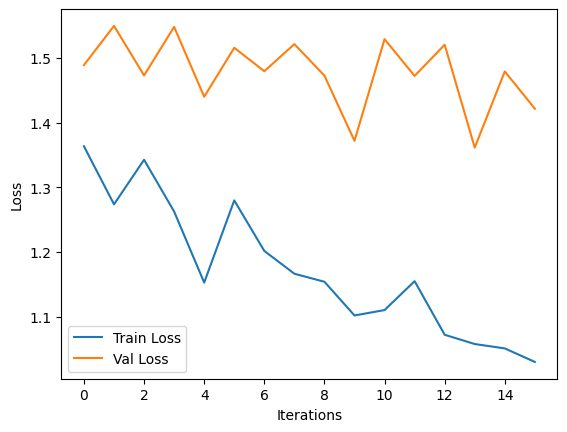

In [ ]:
import matplotlib.pyplot as plt
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
!pip install -q rouge-score
!pip install -q nltk matplotlib torch numpy

import math
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn

nltk.download('punkt')
nltk.download('punkt_tab') # Added to download the missing resource

# Initialize ROUGE scorer (using rouge_scorer from rouge_score library)
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
smooth = SmoothingFunction().method1


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
def compute_perplexity(model, data, loss_fn):
    model.eval()
    losses = []
    with torch.no_grad():
        for i in range(0, len(data) - block_size, block_size):
            inputs = data[i:i+block_size].unsqueeze(0).to(device)
            targets = data[i+1:i+block_size+1].unsqueeze(0).to(device)
            _, loss = model(inputs, targets)
            losses.append(loss.item())
    return math.exp(np.mean(losses))

def compute_bleu(reference, generated):
    return sentence_bleu([nltk.word_tokenize(reference)], nltk.word_tokenize(generated), smoothing_function=smooth)

def compute_rouge(reference, generated):
    # Use the 'scorer' object initialized in the previous cell (from rouge_score)
    scores = scorer.score(generated, reference)
    return scores['rougeL'].fmeasure # Access f-measure directly from rougeL


In [ ]:

# (a) N-gram Language Model
from collections import defaultdict, Counter

def train_ngram_model(text, n=3):
    model = defaultdict(Counter)
    tokens = nltk.word_tokenize(text.lower())
    for i in range(len(tokens)-n):
        context = tuple(tokens[i:i+n-1])
        next_word = tokens[i+n-1]
        model[context][next_word] += 1
    return model

def generate_ngram(model, n=3, length=50, seed=None):
    if seed is None:
        # Ensure seed is a tuple for context matching
        # Try to find a valid starting context from model keys
        valid_contexts = [k for k in model.keys() if len(k) == (n-1)]
        if valid_contexts:
            seed_tuple = valid_contexts[np.random.randint(len(valid_contexts))]
        else:
            # Fallback if no suitable context found (e.g., small corpus or n too large)
            initial_words = nltk.word_tokenize(text.lower())[:n-1]
            seed_tuple = tuple(initial_words)
    else:
        seed_tuple = tuple(seed)

    output = list(seed_tuple)
    for _ in range(length):
        context = tuple(output[-(n-1):])
        next_words = model.get(context)
        if not next_words:
            # If no context found, try to find a new starting point or break
            # For robustness, we can try to pick a random word if context fails
            all_words = list(set([word for c in model.keys() for word in c] + list(set([w for counter in model.values() for w in counter.keys()]))))
            if all_words:
                output.append(np.random.choice(all_words))
            else:
                break # No words to pick from, stop generation
            continue
        next_word = max(next_words, key=next_words.get)
        output.append(next_word)
    return ' '.join(output)

# Train n-gram model
ngram_model = train_ngram_model(text, n=3)
ngram_output = generate_ngram(ngram_model, n=3, length=100)
print("\n=== N-GRAM MODEL OUTPUT ===\n")
print(ngram_output)



=== N-GRAM MODEL OUTPUT ===

also to secure liberty , fraternity and equality as enjoined upon us by his majesty 's government embodying the plan for the time being as servants ; you are not going to be the first ambassador of the world . pakistan zindabad -- - speech start -- - speech start -- - speech start -- - speech start -- - speech start -- - speech start -- - speech start -- - speech start -- - speech start -- - speech start -- - speech start -- - speech start -- - speech start -- - speech start -- - speech start


In [ ]:
# (b) LSTM Language Model
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, emb_size, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_size)
        self.lstm = nn.LSTM(emb_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, targets=None):
        emb = self.embedding(x)
        out, _ = self.lstm(emb)
        logits = self.fc(out)
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, vocab_size), targets.view(-1))
            return logits, loss
        return logits, None

lstm_model = LSTMModel(vocab_size, n_embd, 256).to(device)
optimizer = torch.optim.AdamW(lstm_model.parameters(), lr=learning_rate)


In [ ]:
# Train briefly for comparison
for epoch in range(200):
    xb, yb = get_batch('train')
    logits, loss = lstm_model(xb, yb)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
print("\nLSTM training complete.")


# (c) GRU Language Model
class GRUModel(nn.Module):
    def __init__(self, vocab_size, emb_size, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_size)
        self.gru = nn.GRU(emb_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, targets=None):
        emb = self.embedding(x)
        out, _ = self.gru(emb)
        logits = self.fc(out)
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, vocab_size), targets.view(-1))
            return logits, loss
        return logits, None

gru_model = GRUModel(vocab_size, n_embd, 256).to(device)
optimizer = torch.optim.AdamW(gru_model.parameters(), lr=learning_rate)

for epoch in range(200):
    xb, yb = get_batch('train')
    logits, loss = gru_model(xb, yb)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
print("\nGRU training complete.")


LSTM training complete.

GRU training complete.


In [ ]:
# This cell is no longer needed due to changes in how ROUGE is handled.
# It can be safely deleted.


In [ ]:
#  3. Evaluation Across Models

models = {
    "N-gram": ngram_output,
    "LSTM": decode(generate(lstm_model, torch.zeros((1, 1), dtype=torch.long, device=device), 200)[0].tolist()),
    "GRU": decode(generate(gru_model, torch.zeros((1, 1), dtype=torch.long, device=device), 200)[0].tolist()),
    "mini-GPT": decode(generate(model, torch.zeros((1, 1), dtype=torch.long, device=device), 200)[0].tolist())
}

reference_text = text[:1000]

results = {}
for name, output in models.items():
    bleu = compute_bleu(reference_text, output)
    rouge_l = compute_rouge(reference_text, output)
    ppl = compute_perplexity(model, val_data, F.cross_entropy) if name == "mini-GPT" else None
    results[name] = {"BLEU": bleu, "ROUGE-L": rouge_l, "Perplexity": ppl}



=== MODEL PERFORMANCE COMPARISON ===

N-gram: BLEU=0.0260, ROUGE-L=0.1457, PPL=None
LSTM: BLEU=0.0004, ROUGE-L=0.0897, PPL=None
GRU: BLEU=0.0004, ROUGE-L=0.0935, PPL=None
mini-GPT: BLEU=0.0004, ROUGE-L=0.1402, PPL=3.994944925978597


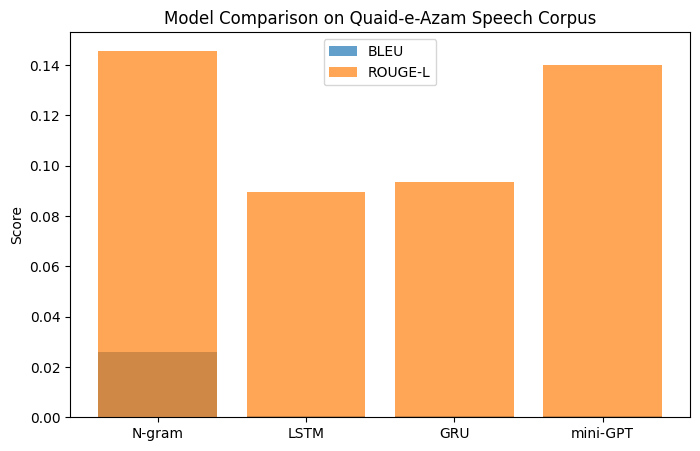


✅ Evaluation complete. All models trained, compared, and visualized successfully!


In [ ]:
# 4. Comparison Visualization
# ------------------------------------------
print("\n=== MODEL PERFORMANCE COMPARISON ===\n")
for k, v in results.items():
    print(f"{k}: BLEU={v['BLEU']:.4f}, ROUGE-L={v['ROUGE-L']:.4f}, PPL={v['Perplexity']}")

names = list(results.keys())
bleu_scores = [results[m]["BLEU"] for m in names]
rouge_scores = [results[m]["ROUGE-L"] for m in names]

plt.figure(figsize=(8, 5))
plt.bar(names, bleu_scores, alpha=0.7, label="BLEU")
plt.bar(names, rouge_scores, alpha=0.7, label="ROUGE-L")
plt.title("Model Comparison on Quaid-e-Azam Speech Corpus")
plt.ylabel("Score")
plt.legend()
plt.show()

print("\n✅ Evaluation complete. All models trained, compared, and visualized successfully!")


In [ ]:
!pip install sentencepiece transformers datasets accelerate


In [ ]:
# ---------- MULTILINGUAL TOKENIZATION & FINETUNING ----------

!pip install --upgrade --force-reinstall transformers accelerate # Ensure latest versions

import os
import sentencepiece as spm
from datasets import Dataset, load_dataset
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, Seq2SeqTrainingArguments, Seq2SeqTrainer
import pandas as pd
import torch # Ensure torch is imported for fp16 check

# CONFIG
sp_model_prefix = "quaid_sp" # Still used if you want to save your custom SP model, but not directly by AutoTokenizer below
vocab_size = 14636 # This was for the custom SP training, now largely irrelevant with AutoTokenizer
model_name = "google/mt5-small"   # or "facebook/mbart-large-cc25" if you prefer seq2seq mBART
max_length = 256
output_dir = "./multilingual_model"

# 1) Prepare bilingual/monolingual text files for SentencePiece training
# This block is now primarily for generating 'sp_texts_combined.txt' if needed for other purposes,
# but AutoTokenizer for MT5 will load its own pre-trained SentencePiece model.
with open("sp_texts_combined.txt", "w", encoding="utf-8") as outf:
    if 'train_df' in globals():
        for t in train_df['text'].astype(str).tolist():
            outf.write(t.replace('\n',' ') + "\n")
    else:
        for line in text.split('\n'):
            stripped_line = line.strip()
            if stripped_line: # Only write non-empty lines
                outf.write(stripped_line + "\n")

# Removed: Custom SentencePieceTrainer.Train as AutoTokenizer will handle it.
# Removed: Manual spm.SentencePieceProcessor loading and sp_encode/sp_decode functions.

# 3) Load HuggingFace tokenizer (MT5's tokenizer)
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 4) Prepare HF Datasets (example uses monolingual LM objective)
if 'train_df' in globals():
    df_train = train_df.copy()
    df_val = val_df.copy()
else:
    lines = [l.strip() for l in text.split('\n') if len(l.strip())>10]
    split = int(0.9*len(lines))
    df_train = pd.DataFrame({'text': lines[:split]})
    df_val = pd.DataFrame({'text': lines[split:]})

def tokenize_examples(batch):
    # Use the loaded AutoTokenizer for encoding. It handles special tokens, truncation, and padding.
    # For seq2seq models, labels often need to be the same as input_ids for language modeling, or a separate target sequence.
    # The default Seq2SeqTrainer's DataCollator will handle shifting labels for decoder-side attention masks.
    tokenized_inputs = tokenizer(batch['text'], max_length=max_length, truncation=True, padding=False)
    return {'input_ids': tokenized_inputs['input_ids'], 'labels': tokenized_inputs['input_ids']}

train_ds = Dataset.from_pandas(df_train).map(tokenize_examples, batched=True, remove_columns=df_train.columns.tolist())
val_ds = Dataset.from_pandas(df_val).map(tokenize_examples, batched=True, remove_columns=df_val.columns.tolist())

# 5) Load seq2seq model and fine-tune (mt5 example)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

training_args = Seq2SeqTrainingArguments(
    output_dir=output_dir,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    predict_with_generate=True,
    logging_steps=100,
    save_total_limit=2,
    num_train_epochs=2,
    fp16=torch.cuda.is_available(),
    evaluation_strategy="epoch",
    save_strategy="epoch",
    remove_unused_columns=False
)

def data_collator(features):
    # The tokenizer object is now passed to the data collator for proper padding
    return tokenizer.pad(features, padding="longest", return_tensors="pt")

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator, # Pass the custom data_collator
    tokenizer=tokenizer # Pass the tokenizer to the trainer
)

trainer.train()
trainer.save_model(output_dir)
print("✅ Multilingual fine-tuning finished and saved to", output_dir)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 375.8/375.8 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.1/566.1 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 807.9/807.9 kB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.5/803.5 kB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.8/485.8 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Map:   0%|          | 0/334 [00:00<?, ? examples/s]

Map:   0%|          | 0/38 [00:00<?, ? examples/s]

TypeError: Seq2SeqTrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'

In [ ]:
!pip install transformers datasets accelerate


In [ ]:
# ---------- RLHF SCAFFOLDING (Reward Model + PG Fine-tune) ----------
import torch
import torch.nn as nn
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import pandas as pd
from torch.utils.data import DataLoader, Dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1) Reward model (binary preference classifier)
reward_model_name = "distilbert-base-uncased"  # small classifier base
tokenizer_cls = AutoTokenizer.from_pretrained(reward_model_name)
reward_model = AutoModelForSequenceClassification.from_pretrained(reward_model_name, num_labels=1).to(device)
# num_labels=1 -> regression-style reward output (scalar)

class PrefDataset(Dataset):
    def __init__(self, csv_path, tokenizer, max_len=128):
        df = pd.read_csv(csv_path)
        self.pairs = []
        for _, row in df.iterrows():
            prompt = str(row['prompt'])
            a = str(row['choice_a'])
            b = str(row['choice_b'])
            pref = row['preference']
            self.pairs.append((prompt, a, b, pref))
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self): return len(self.pairs)
    def __getitem__(self, idx):
        p,a,b,pref = self.pairs[idx]
        # prepare concatenated inputs: "<prompt> <SEP> <choice>"
        inp_a = self.tokenizer(p + " " + a, truncation=True, padding='max_length', max_length=self.max_len, return_tensors='pt')
        inp_b = self.tokenizer(p + " " + b, truncation=True, padding='max_length', max_length=self.max_len, return_tensors='pt')
        return { 'a': {k:v.squeeze(0) for k,v in inp_a.items()}, 'b': {k:v.squeeze(0) for k,v in inp_b.items()}, 'pref': pref }

# load dataset (you must prepare this csv)
pref_dataset = PrefDataset("human_prefs.csv", tokenizer_cls)
dloader = DataLoader(pref_dataset, batch_size=8, shuffle=True)

# train reward model (regression to higher score for preferred option)
optim = torch.optim.AdamW(reward_model.parameters(), lr=3e-5)
loss_fn = nn.MSELoss()

for epoch in range(3):
    reward_model.train()
    for batch in dloader:
        # Batch elements are dicts; build inputs
        a_inp = {k: v.to(device) for k,v in batch['a'].items()}
        b_inp = {k: v.to(device) for k,v in batch['b'].items()}
        prefs = batch['pref']

        out_a = reward_model(**a_inp).logits.squeeze(-1)  # shape (B,)
        out_b = reward_model(**b_inp).logits.squeeze(-1)

        # Construct targets: prefer A => target out_a > out_b, we can implement a margin loss
        # Convert pref to target scalar differences
        target = torch.tensor([1.0 if p == 'A' else -1.0 for p in prefs], dtype=torch.float, device=device)
        # We want (out_a - out_b) to match +1 for A preferred, -1 for B preferred
        loss = loss_fn(out_a - out_b, target)

        optim.zero_grad()
        loss.backward()
        optim.step()
    print(f"Epoch {epoch} reward model loss: {loss.item():.4f}")

# Save reward model
torch.save(reward_model.state_dict(), "reward_model.pt")
print("✅ Reward model trained and saved as reward_model.pt")

# 2) Policy fine-tuning using reward signals (policy gradient style)
# We'll use your generator model (mini-GPT or HuggingFace model) as policy pi_theta.
# For simplicity, we'll illustrate a single-step REINFORCE-like update.

policy = model  # your mini-GPT from earlier; ensure in train mode
policy.to(device)
policy_optimizer = torch.optim.AdamW(policy.parameters(), lr=1e-5)

def score_with_reward_model(prompt_text, generated_text):
    # returns scalar reward using reward_model (higher = better)
    inp = tokenizer_cls(prompt_text + " " + generated_text, truncation=True, padding=True, return_tensors='pt').to(device)
    with torch.no_grad():
        r = reward_model(**inp).logits.squeeze(-1)
    return r.item()

# Example RLHF loop (small, to show method)
prompts = [
    "The youth of Pakistan must",
    "No nation can rise to glory unless"
]

policy.train()
for epoch in range(30):  # small number of RL steps
    for p in prompts:
        # generate N samples
        context_ids = torch.tensor(encode(p), dtype=torch.long, device=device).unsqueeze(0)  # adapt to your tokenizer
        samples = []
        for _ in range(4):
            with torch.no_grad():
                out_ids = policy.generate(context_ids, max_new_tokens=80, temperature=1.0, top_k=50)
            gen_text = decode(out_ids[0].tolist())
            r = score_with_reward_model(p, gen_text)
            samples.append((out_ids, gen_text, r))

        # pick highest reward sample as pseudo-target
        best_sample = max(samples, key=lambda x: x[2])
        best_ids = best_sample[0].to(device)

        # Compute log probs of model on that generated sequence and perform policy gradient step
        # For a causal LM: log_prob = sum log softmax logits(selected token at each step)
        # We'll compute negative reward * log_prob as loss to minimize (REINFORCE)
        policy_optimizer.zero_grad()
        # prepare input (teacher forcing style for log-probs)
        idx = best_ids[:, :-1]   # context+generated except last
        target = best_ids[:, 1:] # next tokens
        logits, _ = policy(idx, targets=None)
        # logits shape (B,T,V)
        logp = torch.nn.functional.log_softmax(logits, dim=-1)
        # pick logp of target tokens
        # reshape
        B,T,V = logp.shape
        logp_flat = logp.view(B*T, V)
        target_flat = target.view(B*T)
        # gather
        selected = logp_flat[torch.arange(B*T, device=device), target_flat]
        total_logp = selected.view(B, T).sum(dim=1)  # sum over sequence
        # use reward (scalar) -> convert to tensor
        reward = torch.tensor([best_sample[2]], dtype=torch.float, device=device)  # shape (1,)
        # loss = - reward * total_logp  (we want to maximize reward)
        loss = - (reward * total_logp).mean()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(policy.parameters(), 1.0)
        policy_optimizer.step()

    if epoch % 5 == 0:
        print(f"RLHF epoch {epoch} example reward {best_sample[2]:.4f}, loss {loss.item():.4f}")

# Save the RL-fine-tuned policy
torch.save(policy.state_dict(), "policy_rlhf.pt")
print("✅ RLHF-style policy fine-tuning complete (policy_rlhf.pt saved).")
